In [2]:
!pip uninstall -y tensorflow tensorflowjs jax jaxlib

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2


In [3]:
!pip install tensorflow==2.18.1
!pip install tensorflowjs==4.22.0 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.9 MB/s eta 0:00:0000:01
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.18.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.18.1 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.18.1 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.2 MB/s eta 0:00:00


In [4]:
!pip install packaging jax==0.4.30 jaxlib==0.4.30

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 MB 10.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflowjs 4.22.0 requires tensorflow-decision-forests>=1.5.0, which is not installed.
tensorflowjs 4.22.0 requires packaging~=23.1, but you have packaging 26.2 which is incompatible.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.30 which is incompatible.
optax 0.2.8 requires jaxlib>=0.5.3, but you have jaxlib 0.4.30 which is incompatible.
orbax-checkpoint 0.11.40 requires jax>=0.6.0, but you have jax 0.4.30 which is incompatible.
flax 0.11.2 requires jax>=0.6.0, but you have jax 0.4.30 which is incompatible.


In [5]:
!pip install tensorflow-decision-forests

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 151.0 MB/s eta 0:00:0000:01
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.1
    Uninstalling tensorflow-2.18.1:
      Successfully uninstalled tensorflow-2.18.1
  Attempting uninstall: tf_keras
    Found existing installation: tf_keras 2.20.0
    Uninstalling tf_keras-2.20.0:
      Successfully uninstalled tf_keras-2.20.0
ERROR

In [6]:
# Muck Pack
import sys
from types import ModuleType

mock_tfdf = ModuleType('tensorflow_decision_forests')

sys.modules['tensorflow_decision_forests'] = mock_tfdf

In [1]:
import tensorflow as tf                                   # type: ignore
from tensorflow.keras import layers, models               # type: ignore
from tensorflow.keras.callbacks import ReduceLROnPlateau  # type: ignore
import numpy as np
import matplotlib.pyplot as plt
import tensorflowjs as tfjs                               # type: ignore
import os
from sklearn.metrics import confusion_matrix              # type: ignore
import seaborn as sns                                     # type: ignore

In [2]:
# Cargar y preprocesar los datos (MINST)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalizar y redimensionar para la CNN
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255

# One-hot encoding de las etiquetas
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Aumento de datos para mejorar generalizacion
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=6,
    zoom_range=0.05,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.05
)
datagen.fit(x_train)

In [4]:
# Arquitectura del modelo (CNN)
model = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(10, activation='softmax')
])

# Mostrar resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,938 (3.33 MB)

 Trainable params: 872,042 (3.33 MB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# Compilar y entrenar el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    min_lr=0.00001,
    verbose=1
)

epochs = 15
batch_size = 128

history = model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=batch_size),                   
    epochs=epochs,
    validation_data=(x_test, y_test_cat),
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9252 - loss: 0.2427 - val_accuracy: 0.6992 - val_loss: 1.1176 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9741 - loss: 0.0832 - val_accuracy: 0.9725 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9803 - loss: 0.0640 - val_accuracy: 0.9869 - val_loss: 0.0385 - learning_rate: 0.0010
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9841 - loss: 0.0532 - val_accuracy: 0.9934 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9875 - val_loss: 0.0349 - learning_rate: 0.0010
Epoch 6/15
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9859 - loss: 0.0460
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9865 - los

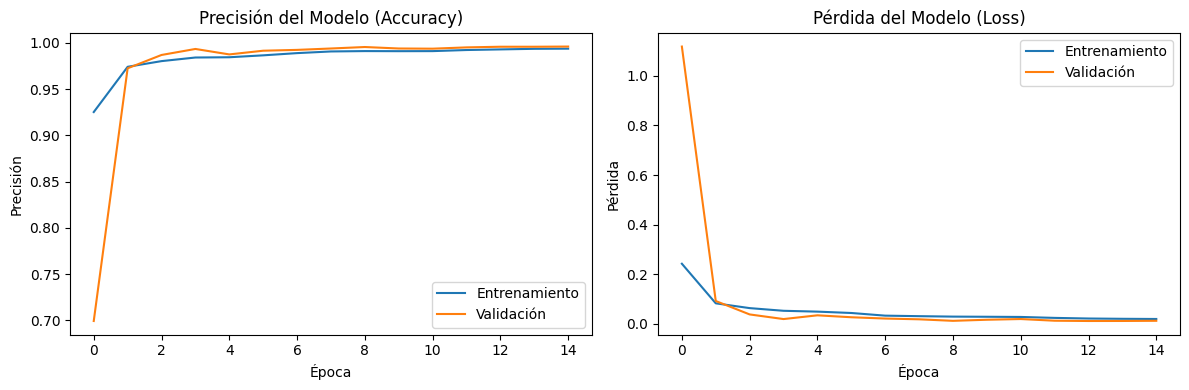

In [6]:
# Gráfica de precisión y pérdida
plt.figure(figsize=(12, 4))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


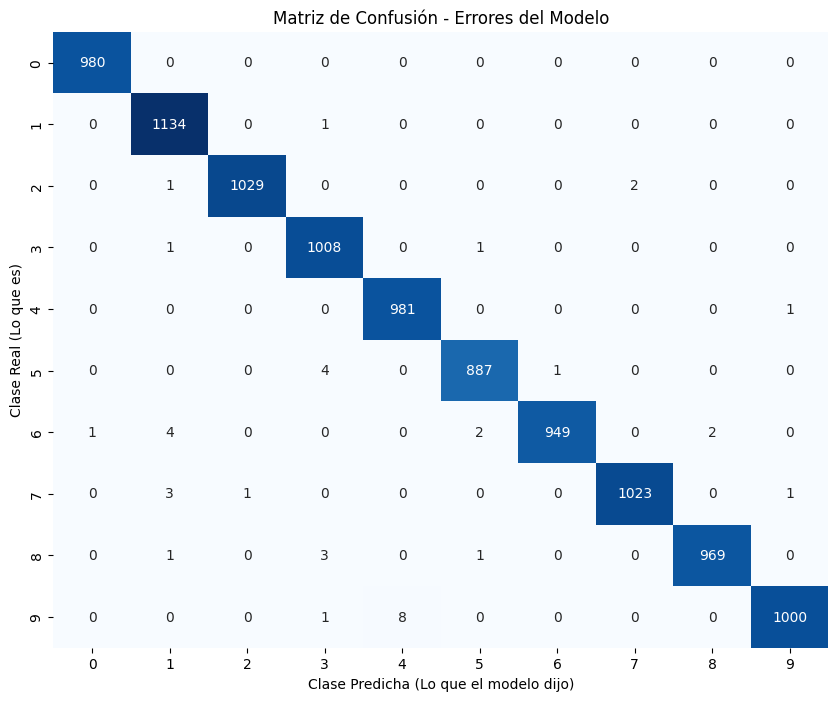

In [7]:
# 1. Obtener las predicciones del modelo en el set de test
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1) # Convertir de probabilidades a clases (0-9)

# 2. Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 3. Graficar usando Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=list(range(10)), yticklabels=list(range(10)))

plt.title('Matriz de Confusión - Errores del Modelo')
plt.ylabel('Clase Real (Lo que es)')
plt.xlabel('Clase Predicha (Lo que el modelo dijo)')
plt.show()

In [8]:
# Evaluar el modelo
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f'Precisión final en el conjunto de test (sin augmentation): {test_acc*100:.2f}%')

Precisión final en el conjunto de test (sin augmentation): 99.60%
